# Ollama + ECG Ischemia Research Prototype

**Pipeline**

ECG image → quality check → canonical filtering → Ollama Qwen2.5-VL → structured ECG analysis → annotated output image

This notebook is a research/educational prototype. It is not a medical diagnostic system.

## Analysis framework

### Reference baseline
- RR interval and rhythm regularity
- visible isoelectric reference
- QRS morphology
- baseline ST/T appearance

### Four research parameters
1. **ST-segment deviation**
2. **T-wave abnormality**
3. **Q-wave abnormality**
4. **ST-T consistency across repeated beats**

### Separate rhythm parameter
**RR interval** — average time gap between visible R peaks and rhythm regularity.

Q waves are reported separately because pathological Q waves are more associated with infarction/prior infarction than ischemia itself. ST/T abnormalities can be associated with ischemia, but they are not automatically proof of ischemia.

In [6]:
# Cell 1 — Install Ollama and Python dependencies

!apt-get update -qq
!apt-get install -y -qq zstd

!curl -fsSL https://ollama.com/install.sh | sh

!pip -q install requests pillow opencv-python-headless numpy matplotlib scipy

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 127332 files and directories currently installed.)
Preparing to unpack .../zstd_1.5.5+dfsg2-2build1.1_amd64.deb ...
Unpacking zstd (1.5.5+dfsg2-2build1.1) ...
Setting up zstd (1.5.5+dfsg2-2build1.1) ...
Processing triggers for man-db (2.12.0-4build2) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [7]:
# Cell 2 — Start the Ollama server

import subprocess
import time
import requests

ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

for _ in range(30):
    try:
        response = requests.get("http://127.0.0.1:11434/api/tags", timeout=2)
        if response.ok:
            print("Ollama server is running.")
            break
    except Exception:
        time.sleep(1)
else:
    raise RuntimeError("Ollama server did not start.")


Ollama server is running.


In [8]:
# Cell 3 — Download Qwen2.5-VL 3B

!ollama pull qwen2.5vl:3b
!ollama list



NAME            ID              SIZE      MODIFIED               
qwen2.5vl:3b    fb90415cde1e    3.2 GB    Less than a second ago    


In [9]:
# Cell 4 — Verify Ollama

payload = {
    "model": "qwen2.5vl:3b",
    "messages": [{"role": "user", "content": "Reply with exactly: OLLAMA_OK"}],
    "stream": False,
    "options": {"temperature": 0},
}

response = requests.post(
    "http://127.0.0.1:11434/api/chat",
    json=payload,
    timeout=120,
)
response.raise_for_status()
print(response.json()["message"]["content"])


OLLAMA_OK


## Upload one ECG graph

For V1, use a **single-lead ECG graph**. A graph with visible grid/time information is preferable because it gives the vision model a reference for timing and morphology.

In [10]:
# Cell 5 — Upload the ECG image

from google.colab import files

uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No image uploaded.")

INPUT_IMAGE = next(iter(uploaded.keys()))
print("Input:", INPUT_IMAGE)


Saving ECG_1.jpg to ECG_1.jpg
Input: ECG_1.jpg


In [11]:
# Cell 6 — Inspect, filter, and standardize the ECG image

import cv2
import numpy as np

def image_quality_report(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Could not read the image.")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    sharpness = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    contrast = float(gray.std())
    low_clip = float((gray <= 3).mean())
    high_clip = float((gray >= 252).mean())
    smooth = cv2.GaussianBlur(gray, (3, 3), 0)
    noise_proxy = float(np.mean(np.abs(gray.astype(np.float32) - smooth.astype(np.float32))))

    return {
        "width": int(w),
        "height": int(h),
        "sharpness_laplacian_variance": round(sharpness, 2),
        "contrast_std": round(contrast, 2),
        "low_clip_fraction": round(low_clip, 4),
        "high_clip_fraction": round(high_clip, 4),
        "noise_proxy": round(noise_proxy, 2),
    }

def preprocess_ecg_image(path, output_path="filtered_ecg.png"):
    img = cv2.imread(path)
    if img is None:
        raise ValueError("Could not read the image.")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if gray.shape[1] < 1600:
        scale = 1600 / gray.shape[1]
        gray = cv2.resize(gray, (1600, int(gray.shape[0] * scale)), interpolation=cv2.INTER_CUBIC)

    denoised = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    filtered = clahe.apply(denoised)

    cv2.imwrite(output_path, filtered)
    return output_path

before = image_quality_report(INPUT_IMAGE)
FILTERED_IMAGE = preprocess_ecg_image(INPUT_IMAGE)
after = image_quality_report(FILTERED_IMAGE)

print("INPUT QUALITY")
print(before)
print("\nFILTERED IMAGE QUALITY")
print(after)
print("\nThe notebook always sends the canonical filtered image to Ollama.")


INPUT QUALITY
{'width': 1200, 'height': 576, 'sharpness_laplacian_variance': 2764.54, 'contrast_std': 34.87, 'low_clip_fraction': 0.0014, 'high_clip_fraction': 0.1861, 'noise_proxy': 7.17}

FILTERED IMAGE QUALITY
{'width': 1600, 'height': 768, 'sharpness_laplacian_variance': 755.34, 'contrast_std': 44.99, 'low_clip_fraction': 0.0, 'high_clip_fraction': 0.0281, 'noise_proxy': 5.08}

The notebook always sends the canonical filtered image to Ollama.


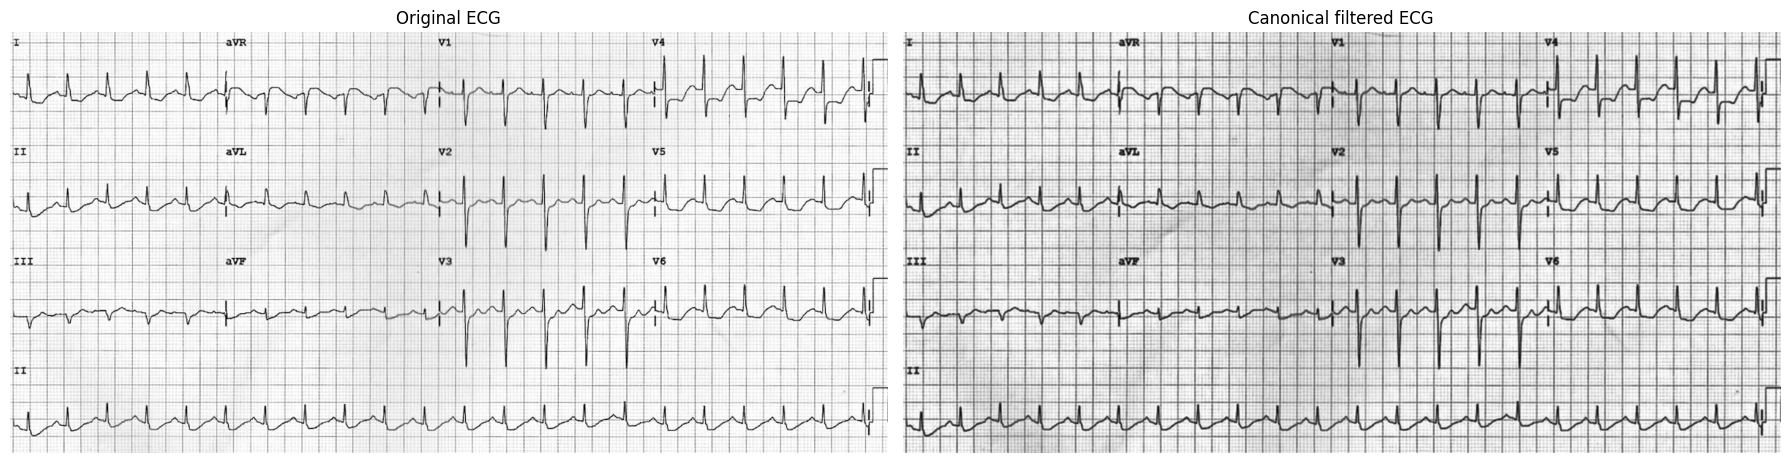

In [12]:
# Cell 7 — Display original and filtered ECG

from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].imshow(Image.open(INPUT_IMAGE))
axes[0].set_title("Original ECG")
axes[0].axis("off")
axes[1].imshow(Image.open(FILTERED_IMAGE), cmap="gray")
axes[1].set_title("Canonical filtered ECG")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [13]:
# Cell 8 — Quality gate before Ollama

def validate_ecg_image(report):
    problems = []
    if report["width"] < 1000:
        problems.append("image width is too small")
    if report["height"] < 300:
        problems.append("image height is too small")
    if report["contrast_std"] < 12:
        problems.append("image contrast is too low")
    if report["sharpness_laplacian_variance"] < 20:
        problems.append("image is probably too blurred")
    if report["low_clip_fraction"] > 0.15 or report["high_clip_fraction"] > 0.15:
        problems.append("large fraction of pixels are clipped")
    return problems

problems = validate_ecg_image(after)
if problems:
    print("IMAGE REJECTED BEFORE OLLAMA")
    for problem in problems:
        print("-", problem)
    raise ValueError("Improve or replace the ECG image before inference.")

print("IMAGE QUALITY CHECK PASSED")


IMAGE QUALITY CHECK PASSED


## ECG knowledge given to Ollama

The model is explicitly told what the baseline means, how to inspect ST/T/Q morphology, how to treat RR separately, not to invent measurements, and to return `indeterminate` when the graph is insufficient.

In [14]:
# Cell 9 — Structured output schema and ECG interpretation prompt

import base64
import json

ECG_SCHEMA = {
    "type": "object",
    "properties": {
        "screening_status": {
            "type": "string",
            "enum": ["possible_ischemic_pattern", "no_obvious_ischemic_pattern", "indeterminate"],
        },
        "image_quality": {"type": "string", "enum": ["adequate", "limited"]},
        "baseline": {
            "type": "object",
            "properties": {
                "heart_rate_bpm": {"type": "number"},
                "rr_interval_ms": {"type": "number"},
                "rr_regularity": {"type": "string"},
                "isoelectric_reference": {"type": "string"},
                "qrs_baseline": {"type": "string"},
                "baseline_st_t": {"type": "string"},
            },
            "required": ["heart_rate_bpm", "rr_interval_ms", "rr_regularity", "isoelectric_reference", "qrs_baseline", "baseline_st_t"],
        },
        "ischemia_parameters": {
            "type": "object",
            "properties": {
                "st_segment_deviation": {"type": "string"},
                "t_wave_abnormality": {"type": "string"},
                "q_wave_abnormality": {"type": "string"},
                "st_t_consistency": {"type": "string"},
            },
            "required": ["st_segment_deviation", "t_wave_abnormality", "q_wave_abnormality", "st_t_consistency"],
        },
        "rr_analysis": {
            "type": "object",
            "properties": {
                "mean_rr_ms": {"type": "number"},
                "regularity": {"type": "string"},
                "visible_r_peaks": {"type": "integer"},
            },
            "required": ["mean_rr_ms", "regularity", "visible_r_peaks"],
        },
        "evidence": {"type": "array", "items": {"type": "string"}},
        "limitations": {"type": "array", "items": {"type": "string"}},
    },
    "required": ["screening_status", "image_quality", "baseline", "ischemia_parameters", "rr_analysis", "evidence", "limitations"],
}

SYSTEM_PROMPT = """
You are an ECG research-analysis assistant.

Analyze the supplied image as a SINGLE-LEAD ECG graph. This is a research
prototype, not a clinical diagnostic system.

ECG REFERENCE KNOWLEDGE:
- The isoelectric baseline is the reference for judging ST-segment displacement.
- Myocardial ischemia/acute coronary syndromes can be associated with ST-segment
  depression/elevation and T-wave abnormalities. These findings are not by
  themselves proof of ischemia and require clinical context.
- Pathological Q waves must be reported separately because they are more
  associated with myocardial infarction/prior infarction than ischemia alone.
- A single lead cannot establish the multi-lead distribution used in clinical
  ECG interpretation and cannot reliably localize an ischemic region.
- Do not invent measurements that are not visible.
- If grid/time calibration is absent, numerical timing must be described as approximate.
- If waveform quality is insufficient, return indeterminate rather than guessing.

WITHIN-RECORDING BASELINE:
First describe the visible baseline: R-R spacing, rhythm regularity, isoelectric
reference, QRS morphology, and baseline ST/T appearance.

FOUR RESEARCH ISCHEMIA PARAMETERS:
1. ST-segment deviation relative to the visible isoelectric reference.
2. T-wave abnormality: inversion, unusual amplitude, asymmetry, or morphology.
3. Q-wave abnormality: unusually deep/wide Q morphology when clearly visible.
4. ST-T consistency across multiple consecutive beats.

SEPARATE RHYTHM PARAMETER:
R-R interval: estimate the average time between visible R peaks and describe
regularity. Do not treat RR abnormality as an ischemia marker.

STATUS:
- possible_ischemic_pattern: one or more visible findings may be compatible with
  ischemia, while acknowledging the single-lead limitation.
- no_obvious_ischemic_pattern: no obvious ischemic morphology is visible.
- indeterminate: quality, calibration, or available lead information is too limited.

Never provide a medical diagnosis. Never provide a fake probability percentage.
"""

USER_PROMPT = """
Analyze this ECG graph using the exact framework in the system instructions.

Return ONLY the requested JSON object.

Requirements:
- Start with the recording baseline.
- Analyze all four research ischemia parameters.
- Separately analyze the R-R interval.
- Distinguish observed findings from uncertainty.
- Do not invent lead names, amplitudes, time scales, or clinical history.
- If a numerical value cannot be read from the graph, use an approximate value
  only when visually reasonable; otherwise report the limitation.
"""

def image_to_base64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")


In [15]:
# Cell 10 — Send ONLY the filtered image to Ollama

image_b64 = image_to_base64(FILTERED_IMAGE)

payload = {
    "model": "qwen2.5vl:3b",
    "messages": [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_PROMPT, "images": [image_b64]},
    ],
    "stream": False,
    "format": ECG_SCHEMA,
    "options": {"temperature": 0},
}

response = requests.post(
    "http://127.0.0.1:11434/api/chat",
    json=payload,
    timeout=300,
)
response.raise_for_status()

ollama_result = response.json()
raw_json = ollama_result["message"]["content"]
print(raw_json)


{
  "screening_status": "indeterminate",
  "image_quality": "adequate",
  "baseline": {
    "heart_rate_bpm": 70,
    "rr_interval_ms": 1000,
    "rr_regularity": "regular",
    "isoelectric_reference": "present",
    "qrs_baseline": "present",
    "baseline_st_t": "present"
  },
  "ischemia_parameters": {
    "st_segment_deviation": "present",
    "t_wave_abnormality": "present",
    "q_wave_abnormality": "present",
    "st_t_consistency": "present"
  },
  "rr_analysis": {
    "mean_rr_ms": 1000,
    "regularity": "regular",
    "visible_r_peaks": 10
  },
  "evidence": [
    "possible_ischemic_pattern"
  ],
  "limitations": [
    "grid_time_calibration_absent",
    "waveform_quality_insufficient"
  ]
}


In [19]:
{
    "ischemia_parameters": {
    "st_segment_deviation": "present",
    "t_wave_abnormality": "present",
    "q_wave_abnormality": "present",
    "st_t_consistency": "present"
  },
  "rr_analysis": {
    "mean_rr_ms": 1000,
    "regularity": "regular",
    "visible_r_peaks": 10
  },
  "evidence": [
    "possible_ischemic_pattern"
  ],
  "limitations": [
    "grid_time_calibration_absent",
    "waveform_quality_insufficient"
  ]
}

{'ischemia_parameters': {'st_segment_deviation': 'present',
  't_wave_abnormality': 'present',
  'q_wave_abnormality': 'present',
  'st_t_consistency': 'present'},
 'rr_analysis': {'mean_rr_ms': 1000,
  'regularity': 'regular',
  'visible_r_peaks': 10},
 'evidence': ['possible_ischemic_pattern'],
 'limitations': ['grid_time_calibration_absent',
  'waveform_quality_insufficient']}

In [21]:
# Cell 11 — Parse and display the result

result = json.loads(raw_json)

print("SCREENING STATUS")
print(result["screening_status"])

print("\nBASELINE")
for key, value in result["baseline"].items():
    print(f"{key}: {value}")

print("\nFOUR ISCHEMIA PARAMETERS")
for key, value in result["ischemia_parameters"].items():
    print(f"{key}: {value}")

print("\nR-R ANALYSIS")
for key, value in result["rr_analysis"].items():
    print(f"{key}: {value}")

print("\nEVIDENCE")
for item in result["evidence"]:
    print("-", item)

print("\nLIMITATIONS")
for item in result["limitations"]:
    print("-", item)


SCREENING STATUS
indeterminate

BASELINE
heart_rate_bpm: 70
rr_interval_ms: 1000
rr_regularity: regular
isoelectric_reference: present
qrs_baseline: present
baseline_st_t: present

FOUR ISCHEMIA PARAMETERS
st_segment_deviation: present
t_wave_abnormality: present
q_wave_abnormality: present
st_t_consistency: present

R-R ANALYSIS
mean_rr_ms: 1000
regularity: regular
visible_r_peaks: 10

EVIDENCE
- possible_ischemic_pattern

LIMITATIONS
- grid_time_calibration_absent
- waveform_quality_insufficient


In [26]:
# Cell -  Parse and display the result

result = json.loads(raw_json)

print("\nFOUR ISCHEMIA PARAMETERS")
for key, value in result["ischemia_parameters"].items():
    print(f"{key}: {value}")

print("\nR-R ANALYSIS")
for key, value in result["rr_analysis"].items():
    print(f"{key}: {value}")

print("\nEVIDENCE")
for item in result["evidence"]:
    print("-", item)



FOUR ISCHEMIA PARAMETERS
st_segment_deviation: present
t_wave_abnormality: present
q_wave_abnormality: present
st_t_consistency: present

R-R ANALYSIS
mean_rr_ms: 1000
regularity: regular
visible_r_peaks: 10

EVIDENCE
- possible_ischemic_pattern


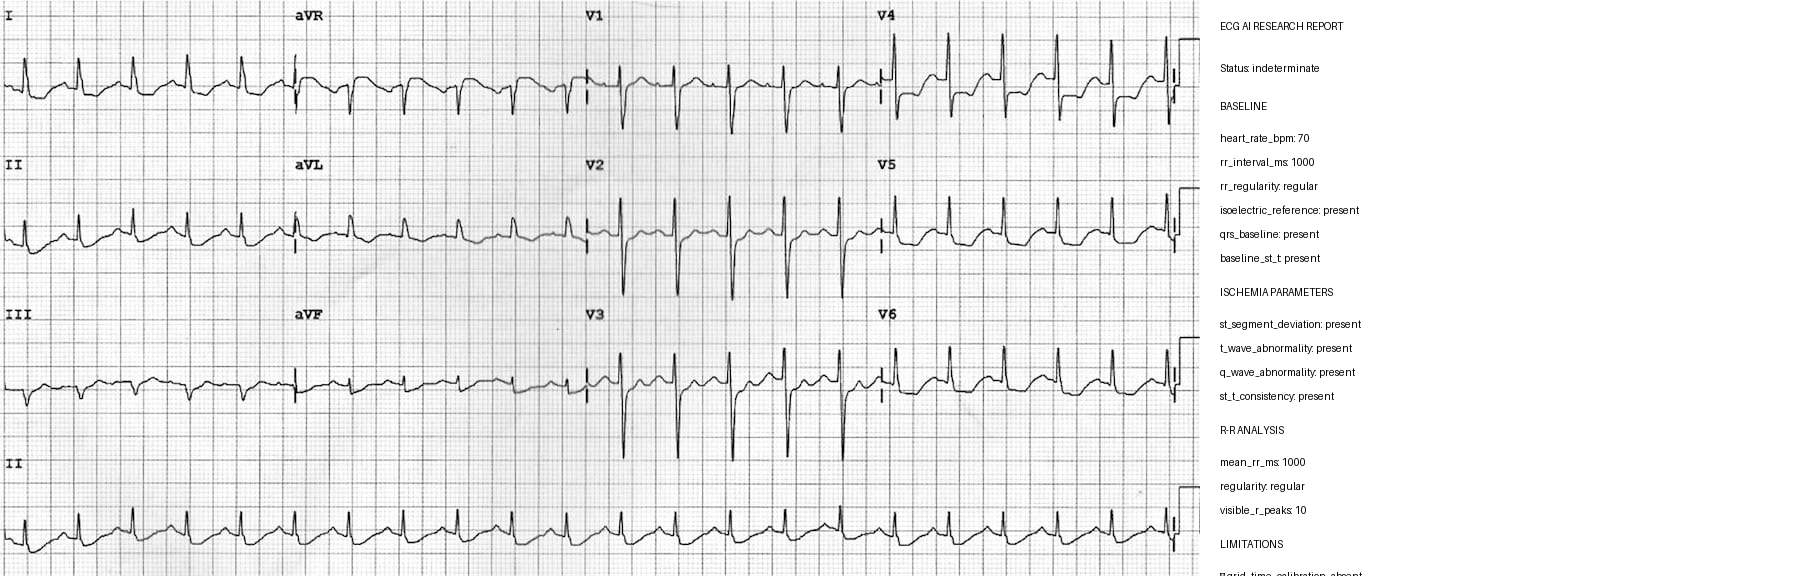

In [27]:
# Cell 12 — Create an annotated ECG report image

from PIL import Image, ImageDraw, ImageFont

base = Image.open(INPUT_IMAGE).convert("RGB")
max_height = 900
if base.height > max_height:
    scale = max_height / base.height
    base = base.resize((int(base.width * scale), max_height))

panel_width = 620
canvas = Image.new("RGB", (base.width + panel_width, base.height), "white")
canvas.paste(base, (0, 0))
draw = ImageDraw.Draw(canvas)

try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 20)
    small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 15)
    bold = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 22)
except Exception:
    font = small = bold = ImageFont.load_default()

x = base.width + 20
y = 20
draw.text((x, y), "ECG AI RESEARCH REPORT", fill="black", font=bold)
y += 42
draw.text((x, y), f"Status: {result['screening_status']}", fill="black", font=font)
y += 38

draw.text((x, y), "BASELINE", fill="black", font=bold)
y += 32
for key, value in result["baseline"].items():
    draw.text((x, y), f"{key}: {value}"[:70], fill="black", font=small)
    y += 24

y += 10
draw.text((x, y), "ISCHEMIA PARAMETERS", fill="black", font=bold)
y += 32
for key, value in result["ischemia_parameters"].items():
    draw.text((x, y), f"{key}: {value}"[:70], fill="black", font=small)
    y += 24

y += 10
draw.text((x, y), "R-R ANALYSIS", fill="black", font=bold)
y += 32
for key, value in result["rr_analysis"].items():
    draw.text((x, y), f"{key}: {value}"[:70], fill="black", font=small)
    y += 24

y += 10
draw.text((x, y), "LIMITATIONS", fill="black", font=bold)
y += 32
for item in result["limitations"][:4]:
    words = item.split()
    line = ""
    for word in words:
        candidate = (line + " " + word).strip()
        if len(candidate) > 55:
            draw.text((x, y), "• " + line, fill="black", font=small)
            y += 22
            line = word
        else:
            line = candidate
    if line:
        draw.text((x, y), "• " + line, fill="black", font=small)
        y += 22

OUTPUT_IMAGE = "ecg_ollama_analysis.png"
canvas.save(OUTPUT_IMAGE)
display(canvas)


In [29]:
# Cell 13 — Save JSON and download the outputs

with open("ecg_ollama_analysis.json", "w") as f:
    json.dump(result, f, indent=2)

print("Created:")
print("- ecg_ollama_analysis.png")
print("- ecg_ollama_analysis.json")

from google.colab import files
files.download(OUTPUT_IMAGE)
files.download("ecg_ollama_analysis.json")


Created:
- ecg_ollama_analysis.png
- ecg_ollama_analysis.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Later: AD8232 integration

AD8232 samples → standardized ECG plot → same quality/filter gate → Ollama → JSON report.

Do not fabricate a 12-lead ECG from the single AD8232 channel. Before relying on morphology, verify the actual AD8232 module/filter configuration; Analog Devices describes approximately 0.5–40 Hz as an ECG waveform-monitoring configuration and warns that narrower filtering can distort ECG morphology.